# About titanic dataset

- As you know the tragic accident happened that day several innocent lost there life in the mid of the night actually in pitch black night
- It was horroble to imagine the situation there 
- Here in this dataset we have the passengers data who travelled by titanic that day
- This dataset contains many important imformation regarding survivers and dead ones

#### Initializing libraries that have to use in the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df2 = pd.read_csv('test.csv')
df = pd.read_csv('train.csv')
df3 = pd.read_csv('gender_submission.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##### Here we have 891 rows and 12 columns in the train dataset of the titanic

In [3]:
df.shape

(891, 12)

### All the columns details

`Col`

- PassengerId -> Every passengers has unique id
- Survived -> 0 denoted who died and 1 for who survived and it is binary denotion
- Pclass -> Pclass is the class they booked to live in the titanic here are 3 classes 1 > 2 > 3 class and it is ordinal 
- Name -> Name of the passenger
- Sex -> Gender of the passenger
- Age -> Age of the passenger
- SibSp -> siblings that of each passengers
- Parch -> parent child relation
- Ticket -> tickets number of each passengers
- Fare -> total price of the tickets 
- Cabin -> Cabin alloted to the passengers
- Embarked -> port from where the passengers boarded, labeled as: C = Cherbourg, Q = Queenstown, and S = Southampton.

`Obervation`
- Here age, cabin and embarked has null values
- All the data types are correctly assigned 
- Column distribution -
1) numerical col -> PassengerId, Age, SibSp, Parch, Fare, Pclass, Survived
2) categorial col -> Sex, embarked
3) Other col -> Name, Cabin, Ticket 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


`Observation`
- age has 177 null values, percentage = 19.86532
- cabin has 687 null values, percentage =  77.104377
- embarked has 2 null values, percentage = 0.224467

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df['Age'].isnull().value_counts(normalize=True)*100

Age
False    80.13468
True     19.86532
Name: proportion, dtype: float64

In [7]:
df['Cabin'].isnull().value_counts(normalize=True)*100

Cabin
True     77.104377
False    22.895623
Name: proportion, dtype: float64

In [8]:
df['Embarked'].isnull().value_counts(normalize=True)*100

Embarked
False    99.775533
True      0.224467
Name: proportion, dtype: float64

### Task 3
- Task 3. Run df.describe() for numerical columns and df.describe(include='object') for categorical. Write 3 observations from each output.

`Observation`
##### for numerical col
- There nothing very much suspicious, the only thing i can is in the fare feature where min in 0 means passenger travelling free and max is huge 512.32
- price difference for different class
- Maximum travelling from 3rd class
- The correct decision is median because Age has outliers (max=80) which pull the mean up. Always use median when outliers exist.
##### for categorical col
- a lot of missing value in Cabin
- Many ticket number is same around 200 ticket numbers are same, even cabin are same of many passengers
- ticket has 7 freq means there is passenger with 7 same number ticket highest

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### Task 4
- Task 4. Handle missing Age values. First check: is the mean Age different across Pclass? Use groupby. Then fill nulls with the median Age per Pclass — not the overall median. Verify nulls are gone after filling.

`Observation`
- So its a big learning for me actually i dont how to use group function 
- We filled the null values of age with the median to its respective Pclass`s age median
- WE have used median because of outliers present in the age that shifts the mean unwantedly instead use median when outliers present

In [11]:
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))

In [12]:
df['Age'].isnull().sum()

np.int64(0)

### Task 5
- Task 5. Handle missing Embarked (2 nulls) and Cabin (687 nulls) differently. Fill Embarked with mode. For Cabin — don't fill it. Instead create a new binary column Has_Cabin (1 if cabin exists, 0 if null). Explain why in markdown.

`Observation`
- Here first we have to fill missing value of Embarked with any aggregate value, so i have chosen mode to fill it with.
- Why mode because mode means most frequency so it is easy to fill it with mode because it is categorical col also

- Here we have to now make a new col Has_cabin and remove cabin col from data to make it more clear and clean
- now for cabin we need to understand that this column has 77% null values but still we cannot remove this column so i made a new column Has_cabin where i normally put that each passenger has cabin or not he is without cabin

In [13]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [14]:
df['Embarked'].isnull().sum()

np.int64(0)

In [15]:
df['Has_cabin'] = df['Cabin'].isnull().map({True: 0, False: 1})

In [16]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


In [17]:
df.drop(columns='Cabin', inplace=True)

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


### Task 6. 
- After all filling, verify zero nulls remain in columns you handled. Run df.isnull().sum() again. Write a markdown table comparing null counts before vs after your handling.

`Observation`
- Its been clearly seen that before there were null values present in dataset in col embarked, cabin, age and now we handled missing values and filled them with correct approach
- Also filling in cabin col id quite difficult so we made a new col alternate for cabin that will work and also no data is lost`

In [19]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_cabin      0
dtype: int64

### Task 7 (Univariate & survival analysis)
- Plot survival count using df['Survived'].value_counts().plot(kind='bar'). What is the overall survival rate as a percentage? Is the dataset balanced or imbalanced?

`Observation` 
- Survival rate is very low 38.383838 and death rate is 61.616162 which is very high
- Among total passengers around 550 passengers were died and more than 325 were able to survived

<Axes: xlabel='Survived'>

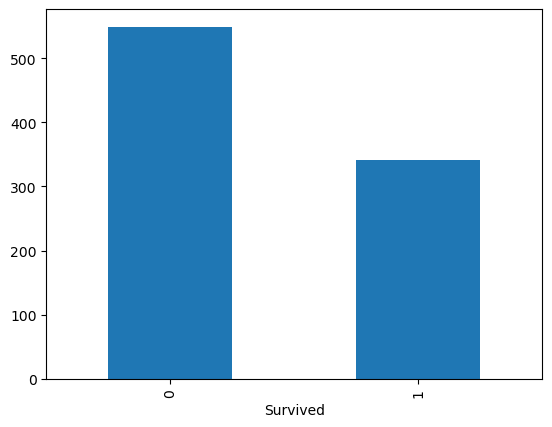

In [20]:
df['Survived'].value_counts().plot(kind='bar')

In [21]:
df['Survived'].value_counts(normalize=True)*100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

### Task 8
- Aalyze survival by Sex and Pclass using groupby. What was the survival rate for males vs females? For each Pclass? Write a markdown table for both.

`Observation`
| Pclass | Female Survived | Female Died | Male Survived | Male Died |
|--------|----------------|-------------|---------------|-----------|
| 1      | 91             | 3           | 45            | 77        |
| 2      | 70             | 6           | 17            | 91        |
| 3      | 72             | 72          | 47            | 300       |

- As we can see female (74.203822%) survival rate is higher than male (18.890815%) and is priortise
- For Pclass the higher your class = the higher survival rate
- For Pclass survival percentage is 1 - 62.962963%, 2 - 47.282609%, 3 - 24.236253%
- You can also clearly see in the countplots on Sex and Pclass survival rate

In [52]:
df.groupby('Sex')['Survived'].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [53]:
df.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [49]:
df.groupby(['Sex', 'Pclass'])['Survived'].mean()*100

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

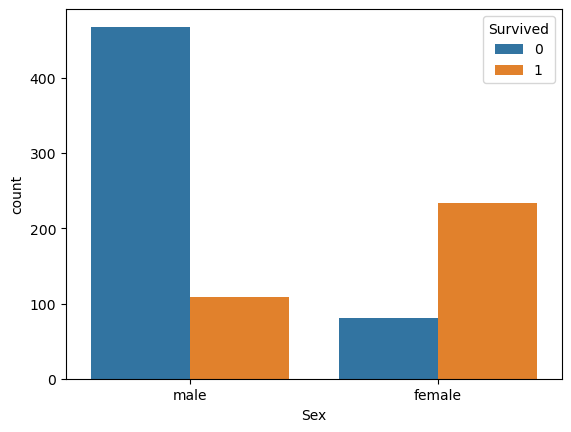

In [50]:
sns.countplot(data=df, x='Sex', hue='Survived')

<Axes: xlabel='Pclass', ylabel='count'>

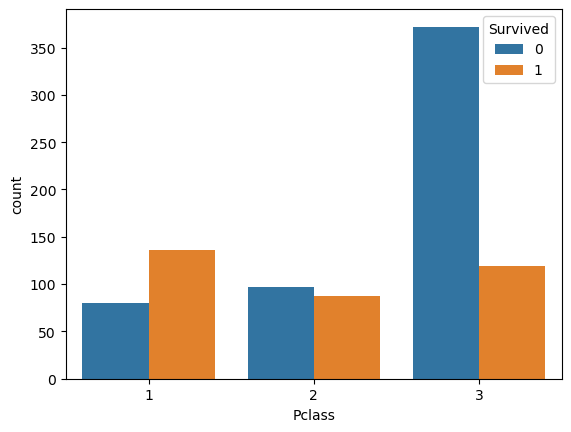

In [51]:
sns.countplot(data=df, x='Pclass', hue='Survived')

### Task 9 
- Plot Age distribution using a histogram with hue='Survived' using seaborn. What age groups had better survival rates? Were children more likely to survive?

`Observation`
- We can clearly see that Surviving rate age group between 20-30 is very low
- surviving rate of 0-10 children is more and for older age group also surviving rate seems low death
- However Age alone is not a strong predictor — Sex and Pclass are far more powerful features as seen in Task 8

<Axes: xlabel='Age', ylabel='Count'>

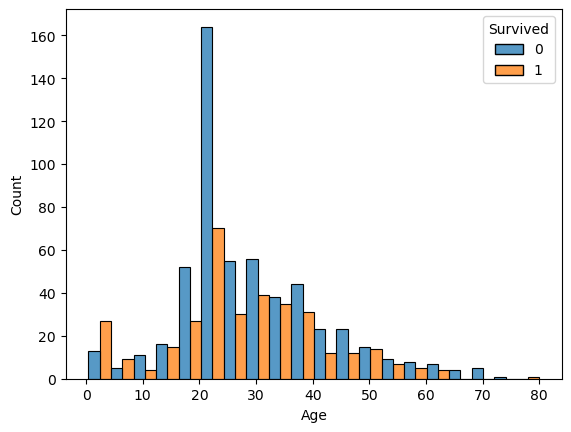

In [59]:
sns.histplot(data=df, x='Age', hue='Survived', bins=20, multiple='dodge')

### Task 10 (Categorical encoding)
- Encode Sex column using Label Encoding manually — without sklearn. Map male=0, female=1 using df['Sex'].map(). Verify the result.

`Obervation`
- For training machine learning model we need to convert categorical col in numerical values that is called `label encoding`

In [ ]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

In [61]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_cabin
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,0


### Task 11 
- Encode Embarked using One-Hot Encoding with pd.get_dummies(). Drop the first column to avoid dummy variable trap. Explain in markdown: why OHE for Embarked but Label Encoding for Sex?

`Observation`
- We ised OneHotEncoding for Embarked column because it is a nominal column which donot have any inherent order and if we use label encoding here then machine learning will priortise higher number columns specifically for linear models
- Also to avoid dummy variable trap and to prevents multicolinearity we drop the very first generated column so that they wont depend on each other
- Sex has only 2 values. Binary columns don't need OHE because there's no false ordering between 0 and 1. Embarked has 3 values — if you label encode C=0, Q=1, S=2, the model thinks S > Q > C which is meaningless

In [67]:
df = pd.get_dummies(df, columns=['Embarked'],drop_first=True, dtype=int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Has_cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,1,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,1,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,24.0,1,2,W./C. 6607,23.4500,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,1,0,0


### Task 12 
- Drop columns that are useless for ML: Name, Ticket, Cabin, PassengerId. Write in markdown why each one is dropped.

`Obervation`
- We are droping columns which are useless for our model training that are passengerid, name, ticket all the columns donot relate with survival or death of passengers 
- PassengerId — just a row number, no predictive value
- Name — 891 unique values, no pattern useful for ML
- Ticket — arbitrary string format, no consistent signal

In [68]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_cabin,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,1,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,27.0,0,0,13.0000,0,0,1
887,1,1,1,19.0,0,0,30.0000,1,0,1
888,0,3,1,24.0,1,2,23.4500,0,0,1
889,1,1,0,26.0,0,0,30.0000,1,0,0
